In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import DataLoader, Dataset, TensorDataset
import torchvision
from pylab import *
from dataclasses import dataclass
import math
import matplotlib as mpl

from src.utils import *

%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.patches as mpatches
import copy
import json

import pylab as plt
plt.rc('text', usetex=True)
plt.rc('font', size=15,family='serif')
# plt.style.use('matplotlibrc')
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FormatStrFormatter
# plt.style.use('tableau-colorblind10')

%matplotlib inline

np.set_printoptions(linewidth=1000)

receptor_labels = np.loadtxt("DoOR_datasets/receptor_labels.txt", dtype='str', delimiter=',')
odorant_labels = np.genfromtxt("DoOR_datasets/odorant_labels.txt", dtype='str', delimiter='\n')
# # For the DoOR datasets, the odorant labels are also provided by their InChIKey
# odorant_labels = np.loadtxt("DoOR_datasets/odorant_labels_InChIKey.txt", dtype='str', delimiter=',')
receptor_responses = np.loadtxt("DoOR_datasets/receptor_responses.csv", delimiter=',')

# exclude all receptors which are not Or
Or_receptor_idx = np.where(np.char.find(receptor_labels, 'Or') == 0)[0]
receptor_labels = receptor_labels[Or_receptor_idx]
receptor_responses = receptor_responses[:,Or_receptor_idx]

## Offline classification of gas sensor dataset

In [4]:
with open('saved_datasets/gas_sensor_dataset/dataset_size_20_baseline_subtraction_True_data.pkl', 'rb') as f:
    dataset = dill.load(f)
with open('saved_datasets/gas_sensor_dataset/dataset_size_20_baseline_subtraction_True_labels.pkl', 'rb') as f:
    labels = dill.load(f)


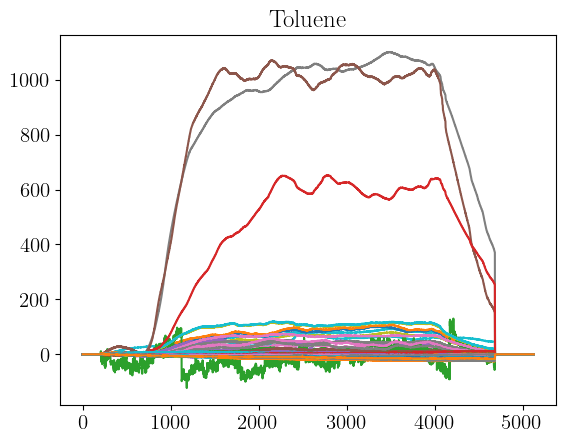

In [5]:
plt.plot(dataset[16])
plt.title(labels[16])
plt.show()

## SVM & Gaussian NB

In [6]:
from sklearn import svm
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

In [7]:
# need to flatten dataset
dataset_flat = [dat.ravel() for dat in dataset]
# one-hot encoding of labels
odorant_names = ["Toluene","Benzene","Methane","CO","Ammonia","Acetone","Acetaldehyde","Methanol","Butanol","Ethylene"]
labels_onehot = np.array([np.where(label == np.array(odorant_names))[0] for label in labels]).ravel()

# split into train/val/test
n_train = int(len(dataset_flat) * 0.6)
n_val = int(len(dataset_flat) * 0.2)
n_test = int(len(dataset_flat) * 0.2)
n_seeds = 10
n_odors = 10
n_pres_range = range(12,13)

test_acc_arr = []

for n_pres in n_pres_range:
    print(f"Running n_pres = {n_pres}")
    test_acc = np.zeros(n_seeds)
    for i, seed in enumerate(range(n_seeds)):
        np.random.seed(seed)
        
        train_dataset, test_dataset, train_labels, test_labels = train_test_split(dataset_flat, labels_onehot, 
                                                    stratify=labels_onehot, random_state=seed, train_size=n_odors * n_pres, test_size=40)
    
        # clf = svm.SVC()
        clf = GaussianNB()
        clf.fit(train_dataset, train_labels)
        test_prediction = clf.predict(test_dataset)
        # test accuracy
        test_acc[i] = clf.score(test_dataset, test_labels)    
    print(f"Test acc: {np.median(test_acc)}")
    test_acc_arr.append(test_acc)

Running n_pres = 12
Test acc: 0.7625


In [8]:
test_acc_arr

[array([0.575, 0.725, 0.775, 0.75 , 0.85 , 0.875, 0.85 , 0.675, 0.85 , 0.725])]

Final test acc: 76.25 +- 3.75, 8.75


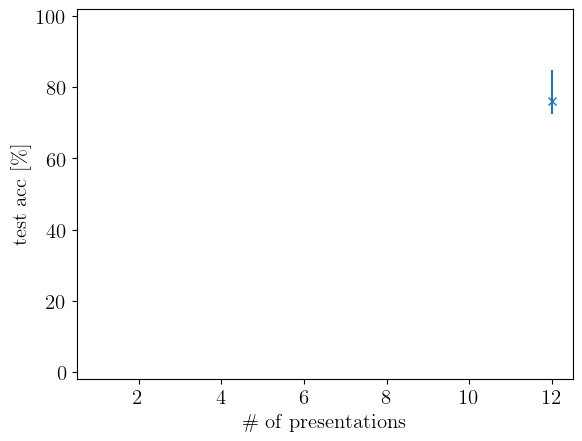

In [9]:
plt.figure()
x = n_pres_range
y = np.array(test_acc_arr) * 100
median = np.median(y, axis=1)
q25, q75 = np.quantile(y, axis=1, q=.25), np.quantile(y, axis=1, q=.75)

print(f"Final test acc: {median[-1]} +- {median[-1]-q25[-1]}, {q75[-1]-median[-1]}")

plt.errorbar(x, median, yerr=np.vstack([median-q25, q75-median]), fmt='x')   
plt.ylabel("test acc [\%]")
plt.xlabel("\# of presentations")
plt.ylim(-2,102)
plt.xlim(0.5, 12.5)
    
plt.show()

## Offline classification of synthetic DM response dataset

In [10]:
with open('saved_datasets/dataset15/dataset_size25_Nodor19_NOR5_voltage.pkl', 'rb') as f:
    dataset_packed = dill.load(f)

In [11]:
dataset = []
labels = []

for ds in dataset_packed.datasets[1:]:
    dataset.append(ds[:][0])
    labels.append(ds[:][1])

dataset = np.array(dataset).reshape(-1, 5, 1000).transpose(0,2,1)
labels = np.array(labels).reshape(-1, 2)[:,1]

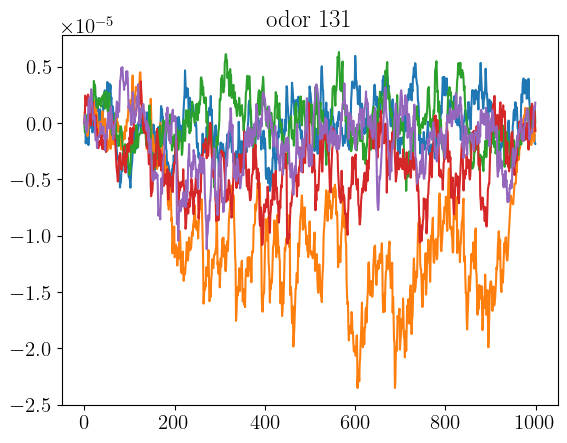

In [12]:
plt.plot(dataset[15])
plt.title("odor " + str(labels[15]))
plt.show()

## SVM & Gaussian NB

In [13]:
from sklearn import svm
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

In [14]:
# need to flatten dataset
dataset_flat = [dat.ravel() for dat in dataset]
# one-hot encoding of labels
labels_onehot = labels

# split into train/val/test
n_train = int(len(dataset_flat) * 0.6)
n_val = int(len(dataset_flat) * 0.2)
n_test = int(len(dataset_flat) * 0.2)
n_seeds = 10
n_pres_range = range(15,16,2)
n_odors = 18

test_acc_arr = []

for n_pres in n_pres_range:
    print(f"Running n_pres = {n_pres}")
    test_acc = np.zeros(n_seeds)
    for i, seed in enumerate(range(n_seeds)):
        np.random.seed(seed)
        
        train_dataset, test_dataset, train_labels, test_labels = train_test_split(dataset_flat, labels_onehot, 
                                                    stratify=labels_onehot, random_state=seed, train_size=n_odors * n_pres, test_size=90)
    
        # clf = svm.SVC()
        clf = GaussianNB()
        clf.fit(train_dataset, train_labels)
        test_prediction = clf.predict(test_dataset)
        # test accuracy
        test_acc[i] = clf.score(test_dataset, test_labels)    
    print(f"Test acc: {np.median(test_acc)}")
    test_acc_arr.append(test_acc)

Running n_pres = 15
Test acc: 0.9388888888888889


Final test acc: 93.88888888888889 +- 1.6666666666666572, 1.3888888888888857


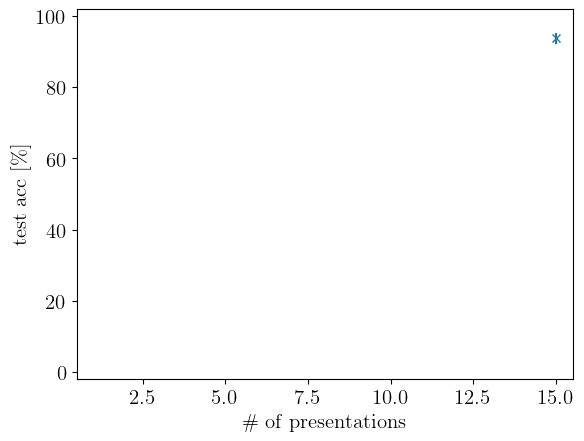

In [15]:
plt.figure()
x = n_pres_range
y = np.array(test_acc_arr) * 100
median = np.median(y, axis=1)
q25, q75 = np.quantile(y, axis=1, q=.25), np.quantile(y, axis=1, q=.75)

print(f"Final test acc: {median[-1]} +- {median[-1]-q25[-1]}, {q75[-1]-median[-1]}")

plt.errorbar(x, median, yerr=np.vstack([median-q25, q75-median]), fmt='x')   
plt.ylabel("test acc [\%]")
plt.xlabel("\# of presentations")
plt.ylim(-2,102)
plt.xlim(0.5, 15.5)
    
plt.show()

Final test acc: 93.88888888888889 +- 1.6666666666666572, 1.3888888888888857


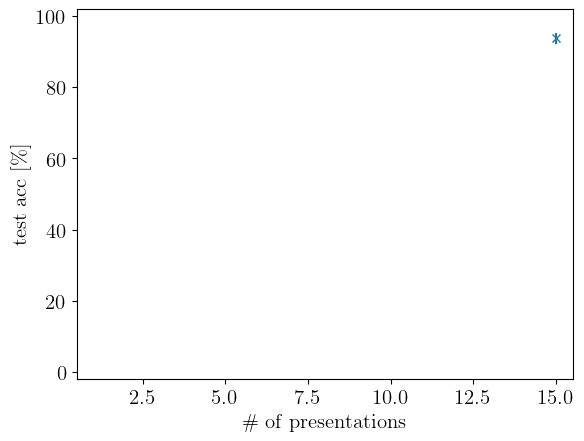

In [16]:
plt.figure()
x = n_pres_range
y = np.array(test_acc_arr) * 100
median = np.median(y, axis=1)
q25, q75 = np.quantile(y, axis=1, q=.25), np.quantile(y, axis=1, q=.75)

print(f"Final test acc: {median[-1]} +- {median[-1]-q25[-1]}, {q75[-1]-median[-1]}")

plt.errorbar(x, median, yerr=np.vstack([median-q25, q75-median]), fmt='x')   
plt.ylabel("test acc [\%]")
plt.xlabel("\# of presentations")
plt.ylim(-2,102)
plt.xlim(0.5, 15.5)
    
plt.show()